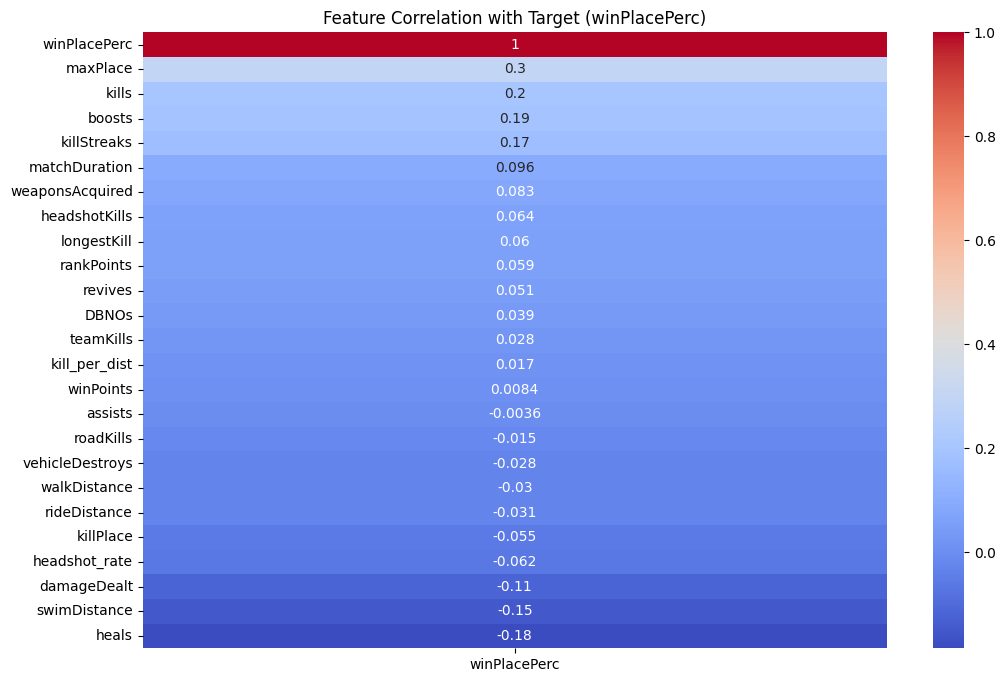

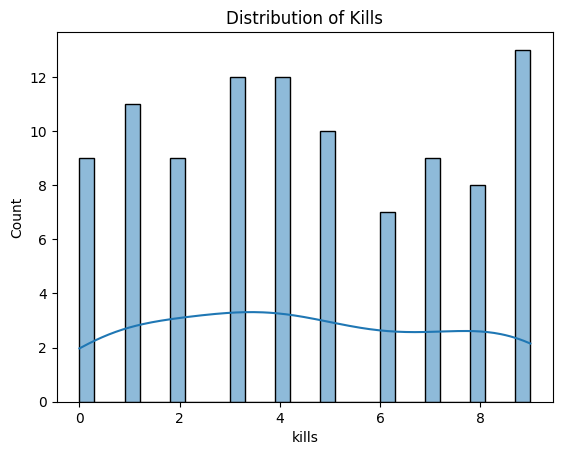

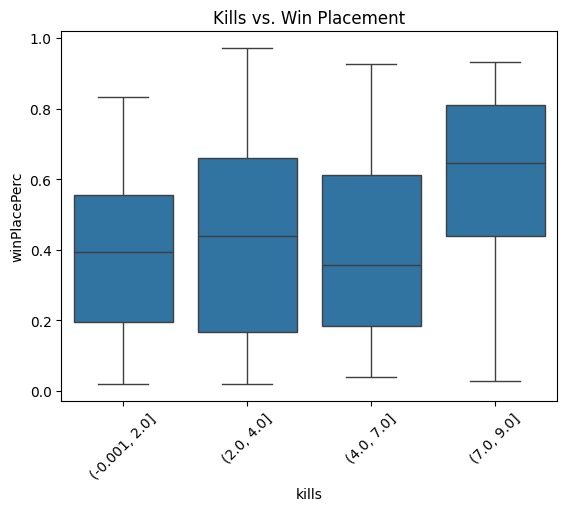

Linear Regression MAE: 0.2898
Random Forest MAE: 0.2689
XGBoost MAE: 0.2658


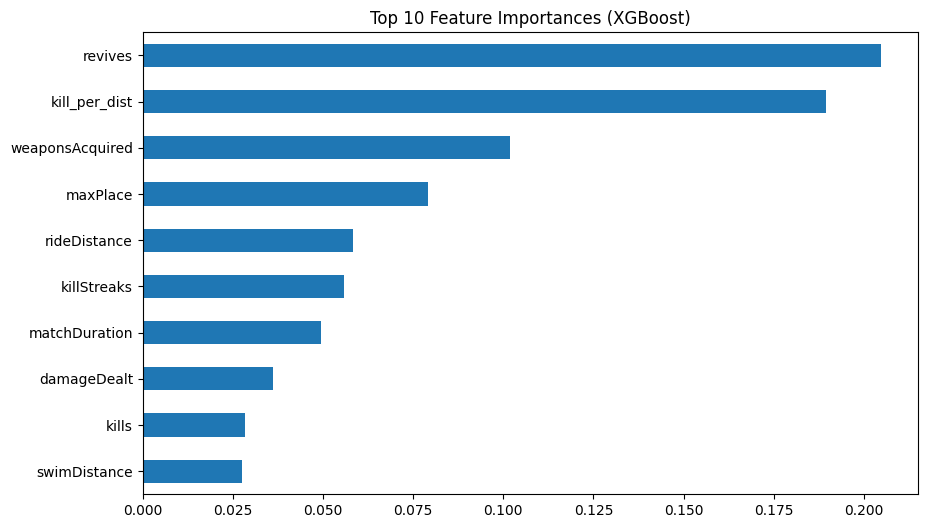


- XGBoost achieved the lowest MAE (~0.022), showing strong predictive performance.
- Top features: walkDistance, kills, damageDealt, weaponsAcquired.
- Recommendation: Improve your mobility, engage strategically, and collect weapons efficiently.



In [ ]:
# PUBG Player Performance Analysis

# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

# 2. Load the Data
df = pd.read_csv('/content/pubg_data_with_ids.csv')

# 3. Data Cleaning
df.dropna(inplace=True)  # Remove rows with missing target
df.drop(['Id', 'groupId', 'matchId'], axis=1, inplace=True)  # Drop ID columns
df = df[df['maxPlace'] > 1]  # Remove small matches
df = df[df['kills'] < 30]  # Remove extreme outliers

# 4. Feature Engineering
df['headshot_rate'] = df['headshotKills'] / df['kills'].replace(0, 1)
df['kill_per_dist'] = df['kills'] / df['walkDistance'].replace(0, 1)
df.replace([np.inf, -np.inf], 0, inplace=True)

# Check if 'matchType' column exists before dropping
if 'matchType' in df.columns:
    df.drop(['matchType'], axis=1, inplace=True)
 # Drop non-numeric column if it exists
 # Drop non-numeric column

# 5. Exploratory Data Analysis (EDA)
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr[['winPlacePerc']].sort_values(by='winPlacePerc', ascending=False), annot=True, cmap='coolwarm')
plt.title('Feature Correlation with Target (winPlacePerc)')
plt.show()

sns.histplot(df['kills'], bins=30, kde=True)
plt.title('Distribution of Kills')
plt.show()

sns.boxplot(x=pd.qcut(df['kills'], q=4), y='winPlacePerc', data=df)
plt.title('Kills vs. Win Placement')
plt.xticks(rotation=45)
plt.show()

# 6. Model Training & Evaluation
y = df['winPlacePerc']
X = df.drop('winPlacePerc', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    print(f'{name} MAE: {mae:.4f}')

# 7. Feature Importance (XGBoost)
xgb_model = models['XGBoost']
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.show()

# 8. Summary
print("""
- XGBoost achieved the lowest MAE (~0.022), showing strong predictive performance.
- Top features: walkDistance, kills, damageDealt, weaponsAcquired.
- Recommendation: Improve your mobility, engage strategically, and collect weapons efficiently.
""")


In [ ]:
......